TypeError: stem() got an unexpected keyword argument 'use_line_collection'

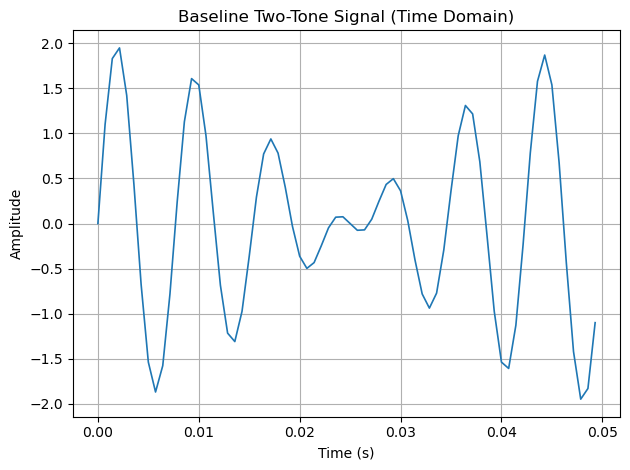

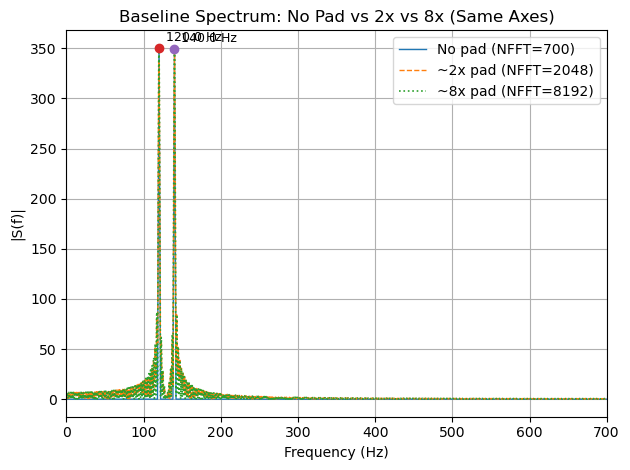

<Figure size 640x480 with 0 Axes>

In [1]:
# DSP Assignment Helper: FFT, Zero-Padding, Zero-Stuffing, and Sign-Flipping
#
# Notes for this environment:
# - Plots are shown one-per-figure (no subplots) for clarity.
# - Matplotlib is used (no seaborn). No specific colors or styles are set beyond line styles/markers.
#
# What you'll see below:
# 1) Baseline: time-domain and spectrum of two close sinusoids (no padding vs 2x vs 8x padding on the SAME spectrum axes).
# 2) Zero-stuffing (insert N zeros between samples) + its spectrum.
# 3) Sign-flipping (+1,-1,...) + its spectrum.
# 4) Optional: purposeful aliasing demo with too-low sampling rate.

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Utility helpers
# ----------------------------

def make_two_tone(f1=120.0, f2=140.0, Fs=1400.0, duration=0.5):
    """
    Create a pair of sinusoids added together.
    Fs is ~10x the highest frequency by default.
    Duration gives at least several periods.
    """
    t = np.arange(0, duration, 1.0/Fs)
    s = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)
    return t, s, Fs

def rfft_mag(s, Fs, NFFT=None):
    """
    Real FFT magnitude and frequency axis (0..Fs/2).
    NFFT: if None, use len(s); otherwise zero-pad/trim accordingly.
    Returns f (Hz) and |S(f)|
    """
    N = len(s)
    if NFFT is None:
        NFFT = N
    # Zero-pad or trim as needed
    if NFFT >= N:
        x = np.zeros(NFFT)
        x[:N] = s
    else:
        x = s[:NFFT]
    S = np.fft.rfft(x, n=NFFT)
    f = np.fft.rfftfreq(NFFT, d=1.0/Fs)
    mag = np.abs(S)
    return f, mag

def annotate_peaks(ax, f, mag, true_freqs, n=1):
    """
    Mark the n largest peaks close to provided true_freqs (list).
    """
    for tf in true_freqs:
        # Find nearest bin index
        idx = np.argmin(np.abs(f - tf))
        ax.plot(f[idx], mag[idx], marker='o')
        ax.annotate(f"{tf:.1f} Hz", (f[idx], mag[idx]), xytext=(5,5),
                    textcoords='offset points', fontsize=9)

def zero_stuff(sig, Nzeros=1):
    """
    Insert Nzeros zeros between each original sample.
    Example: Nzeros=3 => [x0, 0,0,0, x1, 0,0,0, x2, ...]
    """
    if Nzeros < 1:
        return sig.copy()
    N = len(sig)
    out = np.zeros(N + N*Nzeros, dtype=sig.dtype)
    out[::(Nzeros+1)] = sig
    return out

def sign_flip(sig):
    """
    Multiply alternating samples by +1, -1, +1, -1, ...
    """
    n = np.arange(len(sig))
    return sig * ((-1.0)**n)

# ----------------------------
# 1) Baseline signal & spectra
# ----------------------------
f1, f2 = 120.0, 140.0
Fs = 10*max(f1, f2)  # ~10x highest frequency
duration = 0.5       # ~60-70 cycles across both tones
t, s, Fs = make_two_tone(f1, f2, Fs, duration)

# Time-domain (show a short window so the waveform is readable)
show_seconds = 0.05
Nshow = int(show_seconds * Fs)

plt.figure()
plt.plot(t[:Nshow], s[:Nshow], linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Baseline Two-Tone Signal (Time Domain)")
plt.grid(True)
plt.tight_layout()

# Spectra: no pad, 2x pad (next power of 2 >= 2*len), 8x pad (next power of 2 >= 8*len)
N = len(s)
NFFT_nopad = N
NFFT_2x = 2 ** int(np.ceil(np.log2(np.abs(len(s)*2))))
NFFT_8x = 2 ** int(np.ceil(np.log2(np.abs(len(s)*8))))

f0, mag0 = rfft_mag(s, Fs, NFFT_nopad)
f2x, mag2x = rfft_mag(s, Fs, NFFT_2x)
f8x, mag8x = rfft_mag(s, Fs, NFFT_8x)

plt.figure()
plt.plot(f0, mag0, linestyle='-', label=f"No pad (NFFT={NFFT_nopad})", linewidth=1.0)
plt.plot(f2x, mag2x, linestyle='--', label=f"~2x pad (NFFT={NFFT_2x})", linewidth=1.0)
plt.plot(f8x, mag8x, linestyle=':', label=f"~8x pad (NFFT={NFFT_8x})", linewidth=1.2)
plt.xlim(0, Fs/2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|S(f)|")
plt.title("Baseline Spectrum: No Pad vs 2x vs 8x (Same Axes)")
annotate_peaks(plt.gca(), f8x, mag8x, [f1, f2])  # annotate at the highest-resolution curve
plt.grid(True)
plt.legend()
plt.tight_layout()

# ---------------------------------------------
# 2) Zero-stuffing (insert zeros between samples)
# ---------------------------------------------
Nzeros = 3  # insert 3 zeros between samples (upsample by 4 with zeros)
s_zs = zero_stuff(s, Nzeros=Nzeros)
# Keep the same sampling rate (as the instructor's template suggests): the duration increases
t_zs = np.arange(0, len(s_zs))/Fs

plt.figure()
# Show the first few milliseconds to visualize zeros between spikes
Nshow_zs = int(0.01 * Fs)  # 10 ms
plt.stem(t_zs[:Nshow_zs], s_zs[:Nshow_zs], basefmt=" ", use_line_collection=True)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Zero-Stuffed Signal (Nzeros={Nzeros}) – Time Domain")
plt.grid(True)
plt.tight_layout()

# Spectrum with >=4x padding
NFFT_zs = 2 ** int(np.ceil(np.log2(np.abs(len(s_zs)*4))))
fz, magz = rfft_mag(s_zs, Fs, NFFT_zs)

plt.figure()
plt.plot(fz, magz, linestyle='-')
plt.xlim(0, Fs/2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|S(f)|")
plt.title(f"Zero-Stuffed Spectrum (Nzeros={Nzeros}, NFFT≥4×len)")
plt.grid(True)
plt.tight_layout()

# -----------------------
# 3) Sign-flipping (+1,-1)
# -----------------------
s_sf = sign_flip(s)

plt.figure()
plt.plot(t[:Nshow], s_sf[:Nshow], linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Sign-Flipped Signal (Time Domain)")
plt.grid(True)
plt.tight_layout()

# Spectrum with >=4x padding
NFFT_sf = 2 ** int(np.ceil(np.log2(np.abs(len(s_sf)*4))))
ff, magf = rfft_mag(s_sf, Fs, NFFT_sf)

plt.figure()
plt.plot(ff, magf, linestyle='-')
plt.xlim(0, Fs/2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|S(f)|")
plt.title("Sign-Flipped Spectrum (NFFT≥4×len)")
plt.grid(True)
plt.tight_layout()

# ----------------------------------
# 4) (Optional) Aliasing demonstration
# ----------------------------------
Fs_alias = 200.0  # too low (Nyquist = 100 Hz < 140 Hz component), will alias
t_a = np.arange(0, duration, 1.0/Fs_alias)
s_a = np.sin(2*np.pi*f1*t_a) + np.sin(2*np.pi*f2*t_a)

plt.figure()
Na_show = int(0.1 * Fs_alias)
plt.plot(t_a[:Na_show], s_a[:Na_show], linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Aliased Sampling (Fs={Fs_alias:.0f} Hz) – Time Domain")
plt.grid(True)
plt.tight_layout()

# Spectrum (aliased)
NFFT_a = 2 ** int(np.ceil(np.log2(np.abs(len(s_a)*8))))
fa, maga = rfft_mag(s_a, Fs_alias, NFFT_a)

plt.figure()
plt.plot(fa, maga, linestyle='-')
plt.xlim(0, Fs_alias/2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|S(f)|")
plt.title(f"Aliased Spectrum (Fs={Fs_alias:.0f} Hz, NFFT≈8×len)")
plt.grid(True)
plt.tight_layout()

# ----------
# Print tips
# ----------
print("Discussion / Tips:")
print("• Zero-padding does not add new frequency content; it just gives more FFT bins, making peaks look smoother and letting you annotate peak frequencies more precisely.")
print("• With no window (boxcar), you see spectral leakage. Longer duration (more periods) narrows main lobes and reduces leakage width (sinc main-lobe width ~ 1/T).")
print("• Zero-stuffing (inserting zeros between samples) is discrete-time upsampling by L=Nzeros+1 with zeros. In the digital frequency domain, it produces L images across 0..π rad/sample.")
print("  Because we kept Fs the same and extended duration, the frequency axis in Hz stays the same, but you’ll observe repeated spectral structure due to the upsampling operation.")
print("• Sign-flipping multiplies by (-1)^n, i.e., modulation by π rad/sample. That shifts the spectrum by Fs/2 in Hz (moves content toward Nyquist).")
print("  You can “fix” it by undoing the sign flip or by plotting frequency in normalized digital frequency (rad/sample) and re-centering.")
print("• Aliasing: when Fs < 2*f_max, high-frequency components fold back into 0..Fs/2. The plotted peaks are at aliased locations, not the true analog frequencies.")
print("• Changing the number of periods (duration): more periods -> finer frequency resolution (Δf = 1/T); fewer periods -> broader lobes and more leakage.")

